# 01 - Vectors and Linear Combinations

## What Even Are Vectors?

To first understand the role of vectors in linear algebra, we have to define a vector actually is. Here, we will consider an n-dimensional vector to be an ordered list of n real numbers. For example, the list [1, 2] is a 2-dimensional vector.

Vectors display two important operations: multiplication by a scalar and addition with other same-dimensional vectors. Looking at the example vector we set before, we can multiply it by some scalar, like -1, and obtain a new vector with the same dimensions: [-1, -2], or add to it another 2-dimensional vector like [2, 0] to obtain [3, 2].

We can similarly work with vectors in _panchi_ using its `Vector` class, which implements these same operations using Python's syntax and can be inspected by simply printing them, as seen below: 

In [18]:
# Importing separately to not run the import in the notebook cells
import panchi as pan

In [19]:
# Scaling [1, 2] by -1
vector_1 = pan.Vector([1, 2])
scaled_vector = -1 * vector_1
print(scaled_vector)

[-1, -2]


In [20]:
# Adding [1, 2] and [2, 0]
vector_2 = pan.Vector([2, 0])
added_vector = vector_1 + vector_2
print(added_vector)

[3, 2]


We frequently visualize vectors as arrows in a space, especially when working with 2-dimensional vectors like above. These arrows have their tail set at the origin of the space (point [0, 0] for a 2-dimensional space) and their tip at the point where x is its first entry in the list, and y is its second one.

Another benefit of visualizing vectors as arrows is to see how their addition and scaling work. The former amounts to translating one vector so its origin is at the other vector's tip, while the latter amounts to stretching the arrow, only changing its length.

We can easily visualize these vectors and their operations using _panchi_ and its 2-dimensional imaging capabilities (and even animate the additions too! But that cannot be displayed in a Jupyter notebook unfortunately):

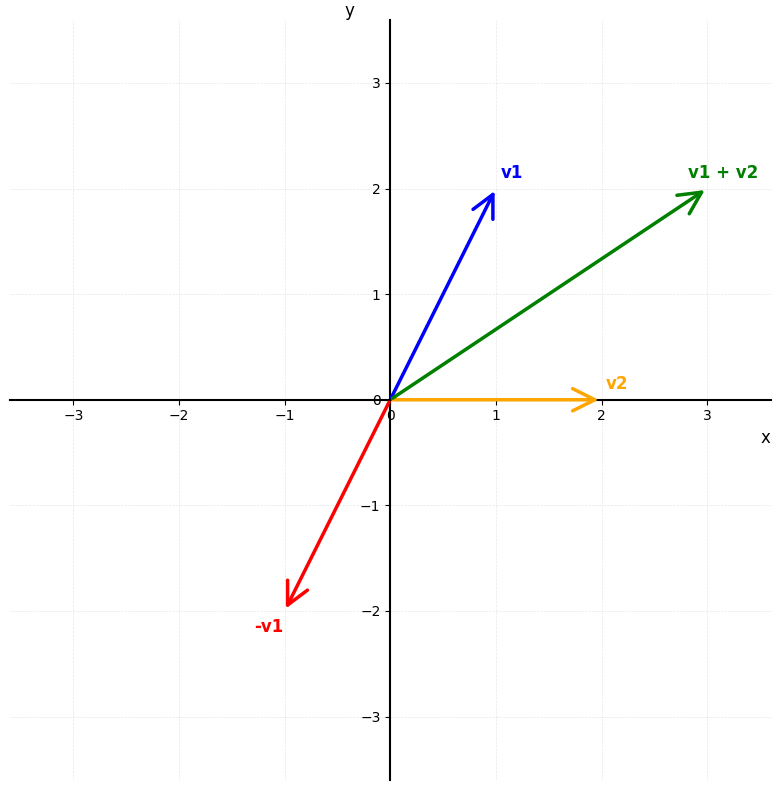

In [21]:
from panchi.visualizations import Animator2D

animator = Animator2D()
animator.plot_vectors(
    vector_1, vector_2, scaled_vector, added_vector,
    colors=['blue', 'orange', 'red', 'green'],
    labels=['v1', 'v2', '-v1', 'v1 + v2']
)


## Linear Combinations

The composition of these vector operations are what we call linear combinations, and understanding them is one of the central topics of linear algebra. We can represent the vectors from the example above as linear combinations of one another, for example:

[3, 2] = 1 * [1, 2] + 1 * [2, 0]

In technical jargon, we say [3, 2] is in the span of [1, 2] and [2, 0], as it can be represented as a linear combination of them. This combination can itself be encoded as a vector [1, 1] since those are the corresponding coefficients that yield [3, 2]. If we collect every vector that is a linear combination of [1, 2] and [2, 0], we construct the span of the set {[1, 2], [2, 0]}.

A span like this is an example of a vector space. Formally, a vector space is a set of vectors equipped with addition and scalar multiplication satisfying a handful of axioms (associativity, distributivity, an additive identity, and so on). For our purposes, every space we care about lives inside some R^n (that is, a space where a vector is an n-dimensional list of real numbers), and a span sitting inside R^n is more precisely called a subspace. To check whether a set of vectors forms a subspace, we only need to verify three properties:

1. It is closed under addition: for any two vectors u and v in the set, their sum u + v is also in the set.
2. It is closed under scalar multiplication: for any vector v in the set and any real scalar c, the product cv is also in the set.
3. It contains the zero vector: the vector with zeroes in every entry, i.e. the vector 0 such that 0 + v = v for any v.

A span automatically satisfies all three, which is exactly why spans are the prototypical example of a subspace in linear algebra.

_panchi_ models subspaces directly with the `VectorSpace` class. We construct one from the list of vectors that span it, and can then ask questions about the resulting space. The most fundamental of these is membership: given some vector, is it in the span/subspace? The `contains` method answers exactly that, by checking whether the vector can be written as a linear combination of the spanning set.

In [ ]:
# Build the subspace spanned by [1, 2] and [2, 0]
space = pan.VectorSpace([vector_1, vector_2])

# [3, 2] = 1*[1, 2] + 1*[2, 0], so it must live in the span
print("contains [3, 2]?", space.contains(added_vector))

# A vector we never constructed by hand but it's still reachable as a combination
print("contains [5, -1]?", space.contains(pan.Vector([5, -1])))

# We can notice that the zero vector, [0, 0], is also reachable as a combination of the two vectors (via the combination 0*[1, 2] + 0*[2, 0]).
# This is true for all subspaces, and the ysis of the ways we can reach the zero vector is a very important topic in linear algebra.
print("contains [0, 0]?", space.contains(pan.Vector([0, 0])))


contains [3, 2]? True
contains [5, -1]? True
contains [0, 0]? True


Because [1, 2] and [2, 0] point in different directions, no scaling of one can ever reproduce the other, which means they are *linearly independent*. This concept of linear dependence/independence is also vital for linear algebra: if, given a set of vectors, there exists some vector that can be represented as a linear combination of the remaining vectors, then this set is said to be linearly dependent, otherwise, it is considered linearly independent.

As a consequence of this independence, the span of [1, 2] and [2, 0] fills the entire plane: every point in R^2 can be written as some linear combination of them. We can confirm this both numerically, with the `dims` and `is_full_rank` properties, and visually, by shading the span.

dimension of the span: 2
fills all of R^2? True


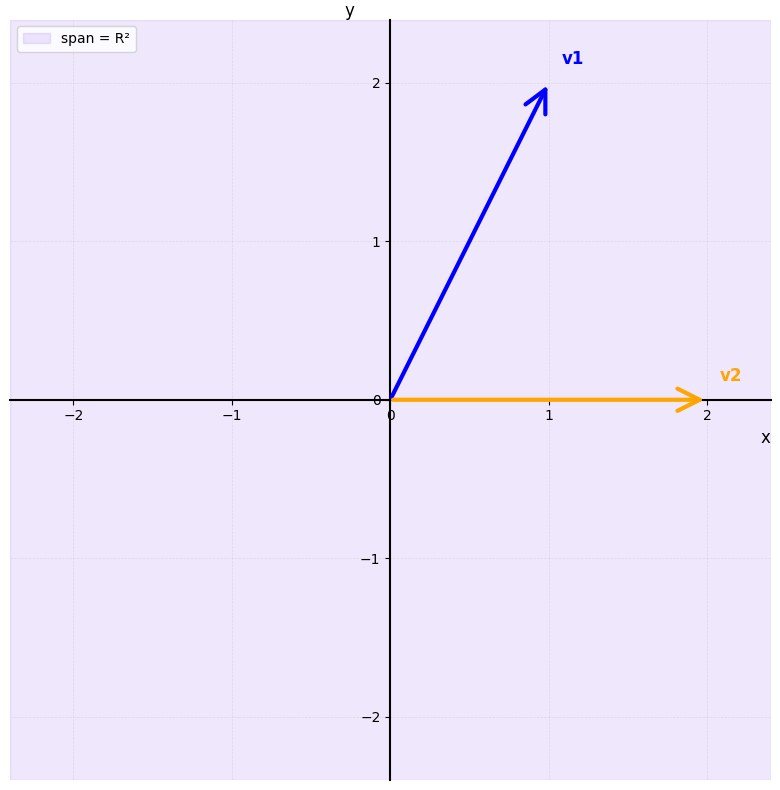

In [23]:
# How big is the span, and does it fill the whole plane?
print("dimension of the span:", space.dims)       # 2 -> a full 2D plane
print("fills all of R^2?", space.is_full_rank)    # True

# Shade the region the span covers (here, the entire plane)
animator.plot_span(space, colors=['blue', 'orange'], labels=['v1', 'v2'])


## When Independence Fails

Independence was the whole reason our span filled the plane, so what happens when it breaks? Let's keep [1, 2], but this time pair it with [2, 4], which is just 2 * [1, 2]. The two vectors point in the *exact same direction*, so the second one adds nothing new: every linear combination still lands on the single line through [1, 2]. The span collapses from a 2D plane down to a 1D line, and a vector like [3, 2] which was easily reachable before now falls outside it entirely.

dimension of the span: 1
fills all of R^2? False
contains [3, 2]? False
contains [-1, -2]? True


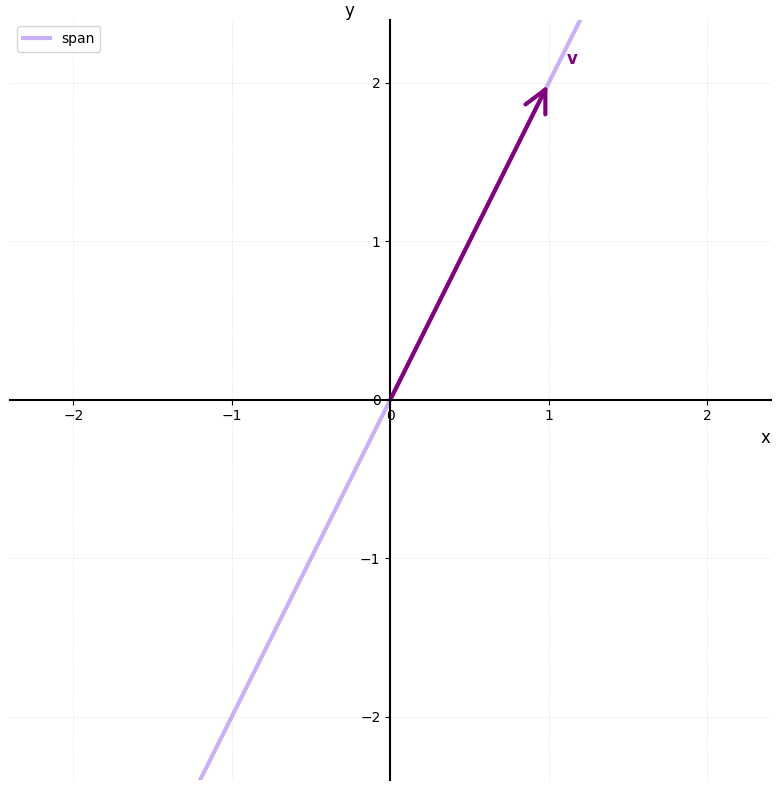

In [ ]:
# [2, 4] = 2 * [1, 2] adds a redundant, linearly dependent direction
dependent_space = pan.VectorSpace([pan.Vector([1, 2]), pan.Vector([2, 4])])

print("dimension of the span:", dependent_space.dims)      # 1, not 2
print("fills all of R^2?", dependent_space.is_full_rank)   # False

# [3, 2] lived comfortably in the full-plane span earlier -- but it is NOT on this line
print("contains [3, 2]?", dependent_space.contains(pan.Vector([3, 2])))      # False
print("contains [-1, -2]?", dependent_space.contains(pan.Vector([-1, -2])))  # True, on the line

# plot_span now draws a single line through the origin instead of shading the plane
animator.plot_span(dependent_space, colors=['purple', 'purple'], labels=['v', '2v'])


## Your Turn

Time to put these ideas to work. Using only `Vector`, `VectorSpace`, and the `Animator2D` you have already met:

**Warm-up (2D).** Start from the vector `u = [2, 1]`.
1. Find a second vector `w` so that `span{u, w}` is just a **line**, and another `w` so that it fills the **whole plane**. Predict `dims` and `is_full_rank` for each *before* you run it, then check yourself.
2. Visualize both spans with `plot_span`. What property of `w` decides which case you land in?

**Challenge (3D).** Let `a = [1, 0, 1]` and `b = [0, 1, 1]`. Their span is a *plane* living inside R^3.
1. Confirm with `dims` and `is_full_rank` that this plane does **not** fill all of R^3.
2. Without simply copying `a` or `b`, find a vector that lies **in** the plane (hint: combine them) and one that lies **outside** it. Verify both with `contains`.
3. Add your outside vector to the spanning set. What happens to `dims` and `is_full_rank`, and why?

**Stretch.** Write a small helper `describe(space)` that prints whether a `VectorSpace` is a point, a line, a plane, or all of its ambient space using only `dims` and `ambient_dims`.